# Sentiment Analysis for Customer Feedback – Product and Service Improvements with Precision

### Exploratory Data Analysis
- Exploratory Data Analysis (EDA) Analyse sentiment patterns across countries and product categories, and identify frequently used keywords.

In [7]:
"""
Import statements for a machine learning project focused on text classification.
Organized by functionality for better maintainability.
"""

from typing import Any
import warnings

# Core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import string
import nltk
from nltk.corpus import stopwords
# import ftfy  # Commented out - install with: pip install ftfy or conda install ftfy
# Add the missing import at the top of your code
from langdetect import detect, LangDetectException

# Classical ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep learning libraries
import torch
from tensorflow.keras.preprocessing.text import Tokenizer


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Utility libraries
from collections import defaultdict, Counter
import joblib
import streamlit as st
import ftfy
# Import the spaCy library for natural language processing
import spacy
# Import required libraries
import plotly.express as px  # Added missing import for Plotly Express
# Configure warnings
warnings.filterwarnings('ignore')  # Suppress compatibility warnings


# Load Preprocessed Sentiment Dataset

In [8]:
# Load the processed sentiment analysis dataset from CSV file
df = pd.read_csv("processed_sentiment_data.csv")

In [9]:
# Display the first 5 rows of the DataFrame to examine the data structure and content
df.head(3)

,review_id,product_category,timestamp,country,rating,review,sentiment,_clean_text,detected_language,is_valid_detection,processed_review
0,REV-50BCBCD9,Sports,2024-09-16 13:44:26+00:00,US,1,"I registered on the website, tried to order a ...",Negative,i registered on the website tried to order a l...,en,True,registered website tried order laptop entered ...
1,REV-6D2B2651,Toys,2024-09-16 18:26:46+00:00,GB,1,Had multiple orders one turned up and driver h...,Negative,had multiple orders one turned up and driver h...,en,True,multiple orders one turned driver phone door n...
2,REV-F7E80372,Toys,2024-09-16 21:47:39+00:00,GB,1,I informed these reprobates that I WOULD NOT B...,Negative,i informed these reprobates that i would not b...,en,True,informed reprobates would going visit sick rel...


# Sentiment Distribution Analysis Across Product Categories

Overall Sentiment Distribution
sentiment
negative    14350
positive     5820
neutral       885
Name: count, dtype: int64


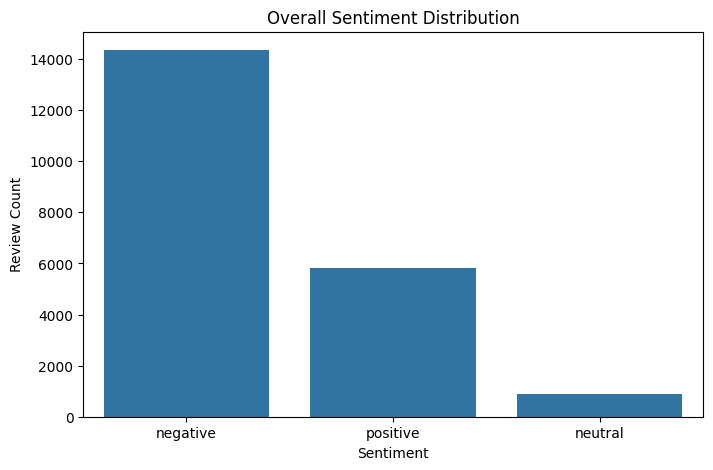


Sentiment by Product Category
sentiment         negative  neutral  positive
product_category                             
Beauty                2003      137       828
Electronics           2033      121       829
Fashion               1968      137       876
Food & Grocery        2009      125       803
Home & Living         2154      116       807
Sports                2130      120       895
Toys                  2053      129       782


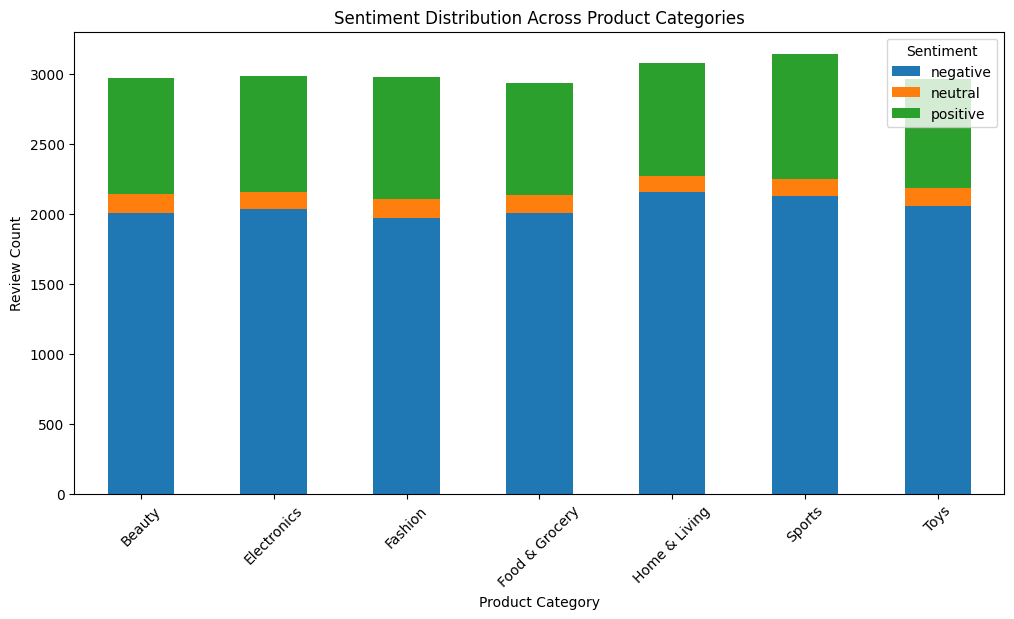


Category Sentiment Percentage
sentiment          negative   neutral   positive
product_category                                
Beauty            67.486523  4.615903  27.897574
Electronics       68.152866  4.056319  27.790815
Fashion           66.018115  4.595773  29.386112
Food & Grocery    68.403132  4.256044  27.340824
Home & Living     70.003250  3.769906  26.226844
Sports            67.726550  3.815580  28.457870
Toys              69.264507  4.352227  26.383266


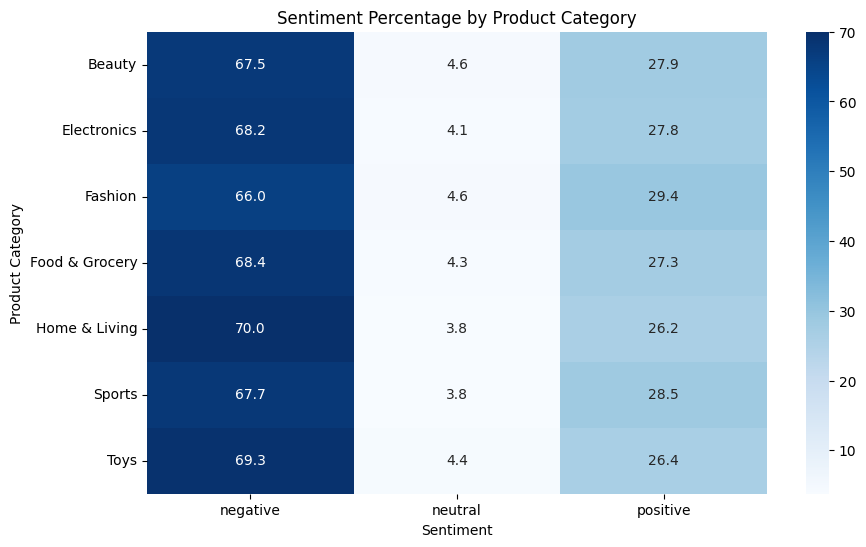


Detected Positive Label: positive
Detected Negative Label: negative

Best Performing Categories
product_category
Fashion           29.386112
Sports            28.457870
Beauty            27.897574
Electronics       27.790815
Food & Grocery    27.340824
Toys              26.383266
Home & Living     26.226844
Name: positive, dtype: float64


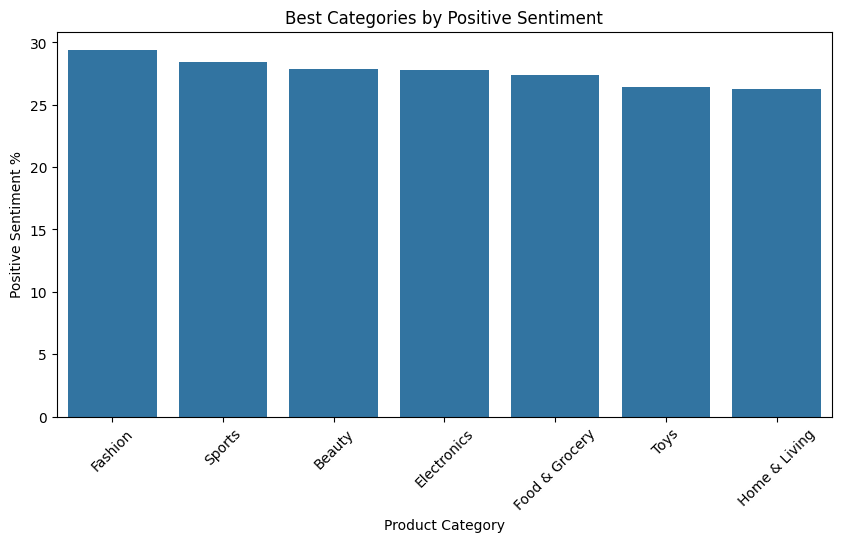


Worst Performing Categories
product_category
Home & Living     70.003250
Toys              69.264507
Food & Grocery    68.403132
Electronics       68.152866
Sports            67.726550
Beauty            67.486523
Fashion           66.018115
Name: negative, dtype: float64


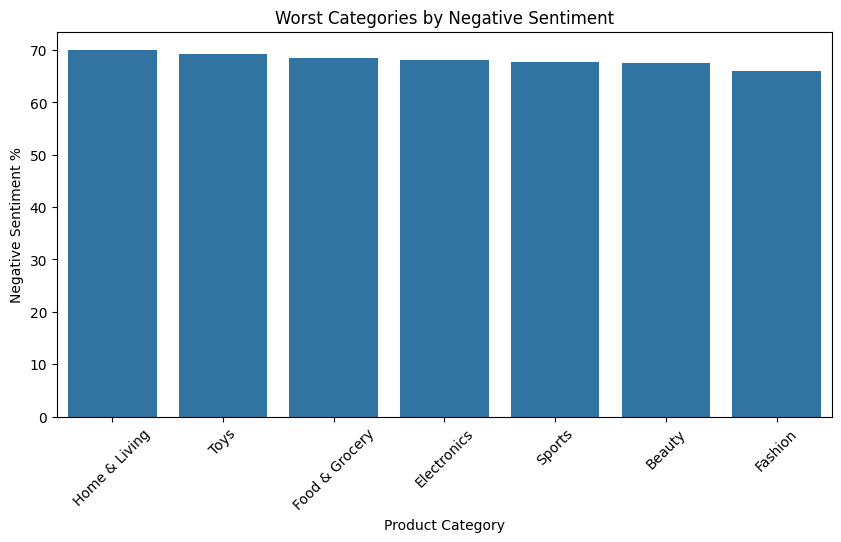

In [10]:
# EXPLAINABILITY NOTE:
# This cell explores sentiment distribution by product category.
# The charts and tables reveal class imbalance and category-level sentiment patterns.

# ======================================================================
# 0. DATA STANDARDISATION
# Purpose: Clean sentiment labels to avoid case-sensitive errors
# ======================================================================

df = df.copy()

# Standardise sentiment values (e.g. Positive → positive)
df["sentiment"] = df["sentiment"].astype(str).str.lower().str.strip()


# ======================================================================
# 1. OVERALL SENTIMENT DISTRIBUTION
# Purpose: Check class balance before modelling
# ======================================================================

# Count frequency of each sentiment class
sentiment_distribution = df["sentiment"].value_counts()

print("Overall Sentiment Distribution")
print(sentiment_distribution)

# Visualise overall sentiment balance
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="sentiment")

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.show()


# ======================================================================
# 2. SENTIMENT DISTRIBUTION BY PRODUCT CATEGORY
# Purpose: Compare sentiment patterns across categories
# ======================================================================

# Create frequency table for category vs sentiment
category_sentiment = pd.crosstab(
    df["product_category"],
    df["sentiment"]
)

print("\nSentiment by Product Category")
print(category_sentiment)

# Stacked bar chart for category-level sentiment breakdown
category_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Sentiment Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Review Count")
plt.legend(title="Sentiment")
plt.xticks(rotation=45)
plt.show()


# ======================================================================
# 3. NORMALISED SENTIMENT ANALYSIS
# Purpose: Compare sentiment proportions fairly across categories
# ======================================================================

# Convert counts into percentage by category
category_sentiment_pct = pd.crosstab(
    df["product_category"],
    df["sentiment"],
    normalize="index"
) * 100

print("\nCategory Sentiment Percentage")
print(category_sentiment_pct)

# Heatmap for sentiment concentration
plt.figure(figsize=(10,6))
sns.heatmap(
    category_sentiment_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Sentiment Percentage by Product Category")
plt.xlabel("Sentiment")
plt.ylabel("Product Category")
plt.show()


# ======================================================================
# 4. AUTO-DETECT SENTIMENT LABELS
# Purpose: Avoid KeyError from hardcoded sentiment names
# ======================================================================

# Detect positive and negative labels automatically
positive_candidates = [c for c in category_sentiment_pct.columns if "pos" in str(c)]
negative_candidates = [c for c in category_sentiment_pct.columns if "neg" in str(c)]

positive_label = positive_candidates[0] if positive_candidates else None
negative_label = negative_candidates[0] if negative_candidates else None

print("\nDetected Positive Label:", positive_label)
print("Detected Negative Label:", negative_label)


# ======================================================================
# 5. BEST PRODUCT CATEGORIES
# Purpose: Identify categories with strongest customer satisfaction
# ======================================================================

if positive_label:

    # Rank categories by positive sentiment %
    best_categories = category_sentiment_pct[positive_label].sort_values(
        ascending=False
    )

    print("\nBest Performing Categories")
    print(best_categories)

    plt.figure(figsize=(10,5))
    sns.barplot(
        x=best_categories.index,
        y=best_categories.values
    )

    plt.title("Best Categories by Positive Sentiment")
    plt.xlabel("Product Category")
    plt.ylabel("Positive Sentiment %")
    plt.xticks(rotation=45)
    plt.show()

else:
    print("No positive sentiment label detected.")


# ======================================================================
# 6. WORST PRODUCT CATEGORIES
# Purpose: Identify categories generating most negative feedback
# ======================================================================

if negative_label:

    # Rank categories by negative sentiment %
    worst_categories = category_sentiment_pct[negative_label].sort_values(
        ascending=False
    )

    print("\nWorst Performing Categories")
    print(worst_categories)

    plt.figure(figsize=(10,5))
    sns.barplot(
        x=worst_categories.index,
        y=worst_categories.values
    )

    plt.title("Worst Categories by Negative Sentiment")
    plt.xlabel("Product Category")
    plt.ylabel("Negative Sentiment %")
    plt.xticks(rotation=45)
    plt.show()

else:
    print("No negative sentiment label detected.")

# Sentiment Analysis by Geography (Country)

In [11]:
# EXPLAINABILITY NOTE:
# This cell analyses sentiment by country.
# Counts show review volume, while percentages make countries comparable despite different sample sizes.

# Sentiment Analysis by Geography (Country)

# ======================================================================
# 1. AGGREGATE SENTIMENT BY COUNTRY
# Purpose: Measure sentiment volume across geographic regions
# ======================================================================

# Count the number of sentiment classes for each country
country_sentiment = pd.crosstab(
    df["country"],
    df["sentiment"]
)

print("Sentiment Distribution by Country")
print(country_sentiment)


# ======================================================================
# 2. CALCULATE SENTIMENT RATES
# Purpose: Standardise sentiment comparison across countries
# ======================================================================

# Convert sentiment counts into percentages per country
country_sentiment_pct = pd.crosstab(
    df["country"],
    df["sentiment"],
    normalize="index"
) * 100

print("\nSentiment Rates by Country (%)")
print(country_sentiment_pct)


# ======================================================================
# 3. VISUALISE SENTIMENT VOLUME
# Purpose: Compare total sentiment counts by country
# ======================================================================

# Reshape data for interactive Plotly chart
country_sentiment_long = country_sentiment.reset_index().melt(
    id_vars="country",
    var_name="sentiment",
    value_name="count"
)

# Grouped bar chart showing sentiment distribution
fig = px.bar(
    country_sentiment_long,
    x="country",
    y="count",
    color="sentiment",
    barmode="group",
    title="Sentiment Distribution by Country"
)

fig.show()


# ======================================================================
# 4. VISUALISE SENTIMENT RATES
# Purpose: Compare sentiment percentages fairly across countries
# ======================================================================

# Reshape percentage data for visualisation
country_sentiment_pct_long = country_sentiment_pct.reset_index().melt(
    id_vars="country",
    var_name="sentiment",
    value_name="percentage"
)

# Stacked bar chart for sentiment percentage comparison
fig = px.bar(
    country_sentiment_pct_long,
    x="country",
    y="percentage",
    color="sentiment",
    title="Sentiment Rate by Country (%)"
)

fig.show()


# ======================================================================
# 5. IDENTIFY BEST PERFORMING COUNTRIES
# Purpose: Find countries with the highest positive customer sentiment
# ======================================================================

# Rank countries by positive sentiment percentage
best_countries = country_sentiment_pct["positive"].sort_values(
    ascending=False
)

print("\nBest Performing Countries")
print(best_countries)

# Visualise the highest positive sentiment countries
fig = px.bar(
    x=best_countries.index,
    y=best_countries.values,
    title="Countries with Highest Positive Sentiment",
    labels={"x": "Country", "y": "Positive Sentiment %"}
)

fig.show()


# ======================================================================
# 6. IDENTIFY WORST PERFORMING COUNTRIES
# Purpose: Find countries with the highest negative customer sentiment
# ======================================================================

# Rank countries by negative sentiment percentage
worst_countries = country_sentiment_pct["negative"].sort_values(
    ascending=False
)

print("\nWorst Performing Countries")
print(worst_countries)

# Visualise countries with highest negative sentiment
fig = px.bar(
    x=worst_countries.index,
    y=worst_countries.values,
    title="Countries with Highest Negative Sentiment",
    labels={"x": "Country", "y": "Negative Sentiment %"}
)

fig.show()

Sentiment Distribution by Country
sentiment  negative  neutral  positive
country                               
AD                0        0         2
AE               65        1        23
AF                1        0         0
AG                1        0         0
AM                7        0         3
...             ...      ...       ...
VG                0        1         0
VI                1        0         0
VN                9        1         6
ZA               44        0         8
ZM                0        0         1

[148 rows x 3 columns]

Sentiment Rates by Country (%)
sentiment    negative     neutral    positive
country                                      
AD           0.000000    0.000000  100.000000
AE          73.033708    1.123596   25.842697
AF         100.000000    0.000000    0.000000
AG         100.000000    0.000000    0.000000
AM          70.000000    0.000000   30.000000
...               ...         ...         ...
VG           0.000000  100.000000  


Best Performing Countries
country
AD    100.0
CI    100.0
UG    100.0
SV    100.0
SO    100.0
      ...  
MC      0.0
MN      0.0
MQ      0.0
MU      0.0
LA      0.0
Name: positive, Length: 148, dtype: float64



Worst Performing Countries
country
IM    100.0
BW    100.0
BZ    100.0
CD    100.0
VI    100.0
      ...  
ET      0.0
CV      0.0
CI      0.0
BB      0.0
ZM      0.0
Name: negative, Length: 148, dtype: float64


# Dashboard dataset and tables

2026-06-27 19:28:55.138 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name 'clean_df' is not defined

# Business Insights & Recommendations

In [ ]:
# ======================================================================
# EXPLAINABILITY NOTE:
# This section translates sentiment analysis results into actionable
# business insights. Instead of only reporting sentiment scores,
# it identifies operational weaknesses, highlights strengths,
# and automatically generates recommendations for stakeholders.
# ======================================================================

st.header("Business Insights")

# ======================================================================
# CREATE FILTERED DATASET
# Purpose:
# Use the filtered dataset from the sidebar. If no filters are applied,
# use the complete dataset.
# ======================================================================

try:
    filtered_df
except NameError:
    filtered_df = clean_df.copy()

# Stop execution if no records remain after filtering
if filtered_df.empty:
    st.warning("No data available for the selected filters.")
    st.stop()

# ======================================================================
# 1. IDENTIFY TOP COMPLAINTS
# ======================================================================

category_pct = pd.crosstab(
    filtered_df["product_category"],
    filtered_df["sentiment"],
    normalize="index"
) * 100

complaints = pd.DataFrame()
satisfaction = pd.DataFrame()

if "negative" in category_pct.columns:

    complaints = (
        category_pct["negative"]
        .sort_values(ascending=False)
        .reset_index(name="Negative Sentiment (%)")
    )

    st.subheader("Top Complaint Categories")

    st.dataframe(complaints, use_container_width=True)

    fig = px.bar(
        complaints,
        x="product_category",
        y="Negative Sentiment (%)",
        color="Negative Sentiment (%)",
        title="Categories with Highest Negative Sentiment"
    )

    st.plotly_chart(fig, use_container_width=True)

# ======================================================================
# 2. IDENTIFY SATISFACTION DRIVERS
# ======================================================================

if "positive" in category_pct.columns:

    satisfaction = (
        category_pct["positive"]
        .sort_values(ascending=False)
        .reset_index(name="Positive Sentiment (%)")
    )

    st.subheader("Top Satisfaction Drivers")

    st.dataframe(satisfaction, use_container_width=True)

    fig = px.bar(
        satisfaction,
        x="product_category",
        y="Positive Sentiment (%)",
        color="Positive Sentiment (%)",
        title="Categories with Highest Positive Sentiment"
    )

    st.plotly_chart(fig, use_container_width=True)

# ======================================================================
# 3. GENERATE BUSINESS RECOMMENDATIONS
# ======================================================================

st.subheader("Business Recommendations")

recommendations = []

# Highest negative category
if not complaints.empty:

    worst = complaints.iloc[0]

    recommendations.append(
        f"Prioritise improvement initiatives for **{worst['product_category']}**, "
        f"which records the highest negative sentiment "
        f"({worst['Negative Sentiment (%)']:.1f}%)."
    )

# Highest positive category
if not satisfaction.empty:

    best = satisfaction.iloc[0]

    recommendations.append(
        f"Maintain and promote **{best['product_category']}**, "
        f"which achieved the highest positive sentiment "
        f"({best['Positive Sentiment (%)']:.1f}%)."
    )

# ======================================================================
# COUNTRY ANALYSIS
# ======================================================================

country_pct = pd.crosstab(
    filtered_df["country"],
    filtered_df["sentiment"],
    normalize="index"
) * 100

if "negative" in country_pct.columns:

    worst_country = country_pct["negative"].idxmax()

    recommendations.append(
        f"Investigate customer experience issues in **{worst_country}**, "
        "as it has the highest proportion of negative reviews."
    )

if "positive" in country_pct.columns:

    best_country = country_pct["positive"].idxmax()

    recommendations.append(
        f"Use **{best_country}** as a benchmark for customer satisfaction "
        "and identify successful practices that can be replicated across other markets."
    )

# ======================================================================
# GENERAL RECOMMENDATION
# ======================================================================

recommendations.append(
    "Continue monitoring customer sentiment over time to evaluate whether improvement initiatives increase positive customer feedback and reduce negative sentiment."
)

# ======================================================================
# DISPLAY RECOMMENDATIONS
# ======================================================================

for i, rec in enumerate(recommendations, start=1):
    st.write(f"**{i}.** {rec}")